# 15 - ML Advisor 回测

基于 `BacktestEngine` 在样本外区间运行 ML advisor，与基准对比。

**前置依赖：** notebook 14 已完成训练，模型存在于 `ml_model_registry`。

**步骤：**
1. 初始化
2. 配置回测参数
3. 运行回测
4. 落库
5. 绩效指标 + 净值曲线 + 最大回撤区间标注
6. 交易统计（按动作分组）
7. 单票贡献（含买入/卖出均价、净价差、约盈亏）
8. 交易明细
9. 个股走势图 + 历史买卖点（区分强度，参考 13_daily_advisor）
10. 对接今日 Live：数据更新（daily_pipeline）+ 当天建议 + 仓位变化 + 归因 + 个股图叠加今日点

## 1. 初始化

In [14]:
%load_ext autoreload
%autoreload 2

import os
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager, FontManager
import pandas as pd
import numpy as np
from datetime import datetime

_cache_dir = matplotlib.get_cachedir()
for _f in os.listdir(_cache_dir):
    if _f.startswith('fontlist'):
        os.remove(os.path.join(_cache_dir, _f))
_fm = FontManager(); fontManager.__dict__.update(_fm.__dict__)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Sans CJK SC', 'Droid Sans Fallback']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

from invest_model.db import get_engine
from invest_model.repositories.stock_pool_repo import StockPoolRepository

engine = get_engine()
pool_repo = StockPoolRepository(engine)
_core = pool_repo.get_pool('core')
_etf = pool_repo.get_pool('etf')
all_pool = pd.concat([_core, _etf], ignore_index=True)
all_codes = all_pool['code'].tolist()
code_name_map = dict(zip(all_pool['code'], all_pool['name']))
print(f'回测标的池: {len(all_codes)} 只')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Matplotlib is building the font cache; this may take a moment.


回测标的池: 6 只


## 2. 配置回测参数

**重要：** 回测起点必须**晚于**模型训练数据末尾，避免 look-ahead 数据泄露。

> **本 notebook 使用 `v1_oos` 模型版本**（训练截止 2024-12-31），需先跑 [14_ml_training.ipynb](./14_ml_training.ipynb) 完成 v1 + v1_oos 双版本训练。
> - 回测主体（cell 6）使用 `version='v1_oos'`，确保 2025-01-01 之后的所有交易日都是真正的样本外
> - 第 10 节"对接今日 Live"使用 `version='v1'`（含最新数据），用于实盘建议

In [15]:
from invest_model.backtest import BacktestConfig
from invest_model.advisor import DecisionConfig

# ── 执行档位（plan: ml-advisor-quality-fix）──
# normal    : 5 档全用，对照组（接近原版行为，但已修过度敏感的 reduce 噪声）
# confident : 仅 strong_buy / buy / clear（小幅 add/reduce 降级为 hold）
# strict    : 仅 strong_buy / clear（最高确定性）
EXEC_TIERS = ['normal', 'confident', 'strict']
PRIMARY_TIER = 'normal'   # 后续单票图/今日 Live 引用此档位的结果

# 决策层基础配置（三档共用，仅切 execution_tier 不同）
DECISION_BASE = DecisionConfig(
    min_trade_size=0.05,
    score_to_position_scale=30.0,
    sell_score_threshold=-0.005,
    min_holding_days=3,
    min_flat_days=2,
    take_profit_min_conditions=3,
    buy_threshold=0.005,
)

def make_cfg(tier: str) -> BacktestConfig:
    return BacktestConfig(
        name=f'ml_advisor_v1_oos_{tier}',
        strategy='ml_target_position',
        start_date='20250101',
        end_date=datetime.now().strftime('%Y%m%d'),
        initial_capital=1_000_000.0,
        fee_rate=0.0003,
        stamp_tax=0.001,
        slippage=0.0005,
        rebalance_days=1,
        min_position_change=DECISION_BASE.min_trade_size,
        max_position_per_stock=0.5,
        benchmark_code='000300.SH',
        decision_config=DECISION_BASE,
        execution_tier=tier,
    )

cfg = make_cfg(PRIMARY_TIER)   # 兼容旧引用
print(f'共 {len(EXEC_TIERS)} 档执行模式: {EXEC_TIERS}, 主档位 = {PRIMARY_TIER}')
print(cfg)

共 3 档执行模式: ['normal', 'confident', 'strict'], 主档位 = normal
BacktestConfig(name='ml_advisor_v1_oos_normal', strategy='ml_target_position', start_date='20250101', end_date='20260513', initial_capital=1000000.0, fee_rate=0.0003, stamp_tax=0.001, slippage=0.0005, rebalance_days=1, min_position_change=0.05, max_position_per_stock=0.5, benchmark_code='000300.SH', decision_config=DecisionConfig(execution_tier='normal', min_trade_size=0.05, score_to_position_scale=30.0, sell_score_threshold=-0.005, min_holding_days=3, min_flat_days=2, take_profit_min_conditions=3, buy_threshold=0.005), execution_tier='normal')


## 3. 运行回测

In [16]:
from invest_model.backtest import BacktestEngine
from invest_model.advisor import StockAdvisor

BACKTEST_MODEL_VERSION = 'v1_oos'    # 训练数据截止 2024-12-31，2025-01-01 之后为真 OOS

# 三档循环：每档独立 advisor + engine，避免冷却状态串档
results_by_tier: dict[str, 'BacktestResult'] = {}
engines_by_tier: dict[str, BacktestEngine] = {}

for _tier in EXEC_TIERS:
    _cfg = make_cfg(_tier)
    _advisor = StockAdvisor(
        engine, version=BACKTEST_MODEL_VERSION,
        decision_config=DECISION_BASE,
        ic_weighting=True,
    )
    _engine_bt = BacktestEngine(
        engine=engine, advisor=_advisor, config=_cfg,
        codes=all_codes, code_name_map=code_name_map,
    )
    _r = _engine_bt.run()
    results_by_tier[_tier] = _r
    engines_by_tier[_tier] = _engine_bt
    print(f'[{_tier:9s}] NAV {len(_r.nav_df)} 行, {len(_r.trades)} 笔交易, '
          f'累计收益 {_r.metrics.get("total_return", 0)*100:+.2f}%, '
          f'换手 {_r.metrics.get("turnover_total", 0):.2f}')

# 兼容旧变量：result / engine_bt / advisor 指向主档位
result = results_by_tier[PRIMARY_TIER]
engine_bt = engines_by_tier[PRIMARY_TIER]
advisor = engine_bt.advisor

11:34:44 | INFO    | FeatureBuilder warmup: 6 只标的 × 20250101~20260513
11:34:47 | INFO    | 加载 ML 模型: 6 只标的 × 3 horizons version=v1_oos ic_weighting=True


[normal   ] NAV 326 行, 126 笔交易, 累计收益 +16.88%, 换手 12.35


11:39:37 | INFO    | FeatureBuilder warmup: 6 只标的 × 20250101~20260513
11:39:39 | INFO    | 加载 ML 模型: 6 只标的 × 3 horizons version=v1_oos ic_weighting=True


[confident] NAV 326 行, 128 笔交易, 累计收益 +17.82%, 换手 12.32


11:45:39 | INFO    | FeatureBuilder warmup: 6 只标的 × 20250101~20260513
11:45:41 | INFO    | 加载 ML 模型: 6 只标的 × 3 horizons version=v1_oos ic_weighting=True


[strict   ] NAV 326 行, 129 笔交易, 累计收益 +17.62%, 换手 12.32


## 4. 落库

In [17]:
from invest_model.backtest import save_backtest_result

run_ids: dict[str, int] = {}
for _tier, _r in results_by_tier.items():
    _id = save_backtest_result(engine, _r)
    run_ids[_tier] = _id
    print(f'  [{_tier:9s}] run_id = {_id}')

run_id = run_ids[PRIMARY_TIER]   # 兼容旧引用

11:51:51 | INFO    | 回测落库完成 run_id=28: nav=326 trades=126


  [normal   ] run_id = 28


11:51:51 | INFO    | 回测落库完成 run_id=29: nav=326 trades=128


  [confident] run_id = 29


11:51:51 | INFO    | 回测落库完成 run_id=30: nav=326 trades=129


  [strict   ] run_id = 30


## 5. 绩效指标 + 净值曲线（三档横向对比）

- **绩效指标**：按 收益 / 风险 / 交易 / 基准 四组展示，每档一列；指标定义对齐 `invest_model.backtest.metrics.PortfolioMetrics`。
- **净值曲线**：三档 NAV 叠加 + 基准对比，下方各档回撤副图。
- 关注重点：**confident / strict 是否在显著降低换手与交易成本的同时维持或提升年化收益**。

In [18]:
metrics = result.metrics   # 兼容旧引用：主档位指标

def _pct(v): return f'{v * 100:+.2f}%' if v is not None else '—'
def _pct_abs(v): return f'{v * 100:.2f}%' if v is not None else '—'
def _num(v): return f'{v:+.4f}' if v is not None else '—'
def _x(v): return f'{v:.2f}' if v is not None else '—'
def _int(v): return f'{int(v)}' if v is not None else '—'

groups = [
    ('收益', [
        ('total_return',  '累计收益',     _pct),
        ('annual_return', '年化收益',     _pct),
        ('annual_vol',    '年化波动率',   _pct_abs),
    ]),
    ('风险', [
        ('max_drawdown',  '最大回撤',     _pct_abs),
        ('sharpe',        '夏普比率',     _num),
        ('sortino',       '索提诺比率',   _num),
        ('calmar',        '卡玛比率',     _num),
    ]),
    ('交易', [
        ('win_rate',           '日度胜率',     _pct_abs),
        ('avg_position_count', '日均持仓只数', _x),
        ('turnover_total',     '累计换手',     _x),
        ('n_days',             '回测交易日',   _int),
    ]),
]
# 至少一个档位拿到了基准就显示
if any(r.metrics.get('benchmark_total_return') is not None for r in results_by_tier.values()):
    groups.append(('基准', [
        ('benchmark_total_return',  '基准累计收益',  _pct),
        ('benchmark_annual_return', '基准年化收益',  _pct),
        ('alpha',                   '年化 Alpha',    _pct),
        ('beta',                    'Beta',          _x),
    ]))

rows = []
for grp, items in groups:
    for key, label, fn in items:
        row = {'分组': grp, '指标': label}
        for _tier in EXEC_TIERS:
            row[_tier] = fn(results_by_tier[_tier].metrics.get(key))
        rows.append(row)

# 总交易笔数额外加一行
trade_row = {'分组': '交易', '指标': '总交易笔数'}
for _tier in EXEC_TIERS:
    trade_row[_tier] = f'{len(results_by_tier[_tier].trades)}'
rows.append(trade_row)

table = pd.DataFrame(rows)
display(table)

# 超额对比汇总
print()
for _tier in EXEC_TIERS:
    _m = results_by_tier[_tier].metrics
    _bench = _m.get('benchmark_total_return')
    if _bench is not None:
        _excess = _m['total_return'] - _bench
        print(f'  [{_tier:9s}] 累计 {_m["total_return"]*100:+6.2f}%  vs 基准 {_bench*100:+6.2f}%  '
              f'超额 {_excess*100:+6.2f}%  Sharpe {_m.get("sharpe", 0):+.2f}  '
              f'换手 {_m.get("turnover_total", 0):.2f}')
    else:
        print(f'  [{_tier:9s}] 累计 {_m["total_return"]*100:+6.2f}%  (无基准)  '
              f'Sharpe {_m.get("sharpe", 0):+.2f}  换手 {_m.get("turnover_total", 0):.2f}')

,分组,指标,normal,confident,strict
0,收益,累计收益,+16.88%,+17.82%,+17.62%
1,收益,年化收益,+12.71%,+13.40%,+13.26%
2,收益,年化波动率,9.55%,9.50%,9.50%
3,风险,最大回撤,8.42%,7.95%,7.95%
4,风险,夏普比率,+1.3307,+1.4106,+1.3949
5,风险,索提诺比率,+2.0761,+2.1930,+2.1742
6,风险,卡玛比率,+1.5092,+1.6866,+1.6682
7,交易,日度胜率,52.94%,52.94%,52.77%
8,交易,日均持仓只数,2.59,2.59,2.59
9,交易,累计换手,12.35,12.32,12.32



  [normal   ] 累计 +16.88%  vs 基准 +29.52%  超额 -12.64%  Sharpe +1.33  换手 12.35
  [confident] 累计 +17.82%  vs 基准 +29.52%  超额 -11.69%  Sharpe +1.41  换手 12.32
  [strict   ] 累计 +17.62%  vs 基准 +29.52%  超额 -11.89%  Sharpe +1.39  换手 12.32


/tmp/ipykernel_1092351/533590369.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


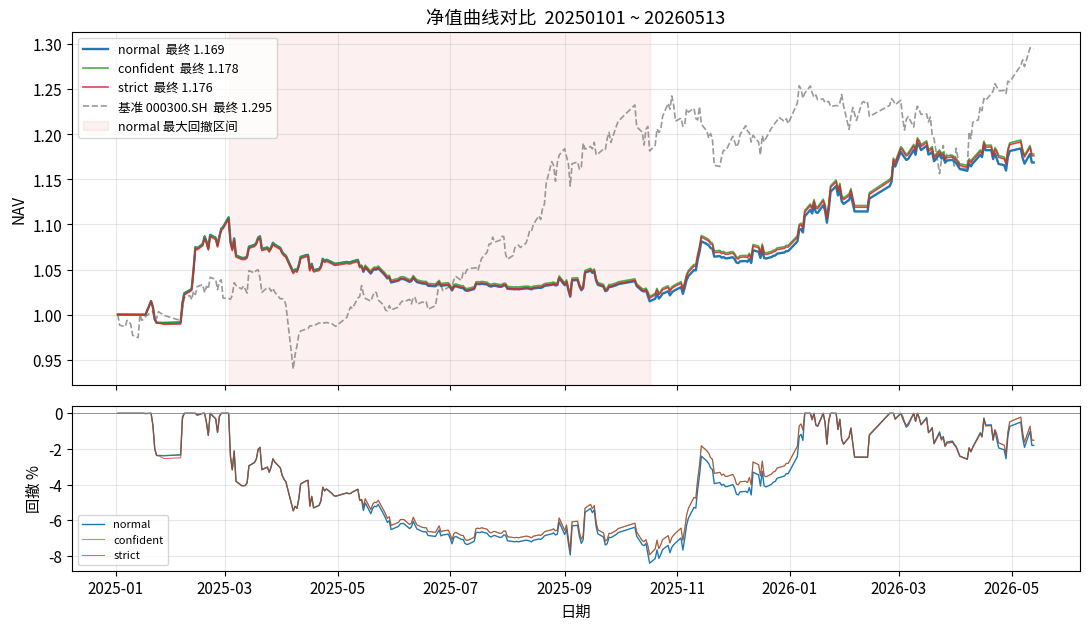


  [normal] 最大回撤: -8.42%
    峰值日: 2025-03-03  NAV=1.1080
    谷底日: 2025-10-17  NAV=1.0147
    下行用时: 153 个交易日
    恢复日:   2026-01-09  耗时 211 个交易日


In [19]:
TIER_COLORS = {
    'normal':    '#1f77b4',  # 蓝
    'confident': '#2ca02c',  # 绿
    'strict':    '#d62728',  # 红
}

# 三档 NAV + 各自回撤
fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(13, 7.0), sharex=True,
    gridspec_kw={'height_ratios': [3, 1.4], 'hspace': 0.08},
)

# 主档位用于回撤标注
nav = results_by_tier[PRIMARY_TIER].nav_df.copy()
nav['date'] = pd.to_datetime(nav['trade_date'], format='%Y%m%d')
nav['cummax'] = nav['nav'].cummax()
nav['drawdown'] = nav['nav'] / nav['cummax'] - 1.0

trough_i = nav['drawdown'].idxmin()
peak_i = nav.loc[:trough_i, 'cummax'].idxmax()
post = nav.loc[trough_i:]
recovery = post[post['nav'] >= nav.loc[peak_i, 'nav']]
recovery_i = recovery.index[0] if not recovery.empty else None

# 上图：三档 NAV + 基准
bench_df = None
if cfg.benchmark_code:
    bench_df = engine_bt._load_benchmark_nav(nav['trade_date'].tolist())
    if bench_df is not None and not bench_df.empty:
        bench_df = bench_df.copy()
        bench_df['date'] = pd.to_datetime(bench_df['trade_date'], format='%Y%m%d')

for _tier, _r in results_by_tier.items():
    _nav = _r.nav_df.copy()
    _nav['date'] = pd.to_datetime(_nav['trade_date'], format='%Y%m%d')
    _final = _nav['nav'].iloc[-1]
    ax.plot(_nav['date'], _nav['nav'],
            color=TIER_COLORS[_tier], linewidth=1.7 if _tier == PRIMARY_TIER else 1.2,
            alpha=1.0 if _tier == PRIMARY_TIER else 0.85,
            label=f'{_tier}  最终 {_final:.3f}', zorder=3)

if bench_df is not None and not bench_df.empty:
    ax.plot(bench_df['date'], bench_df['nav'], color='#888', linewidth=1.2,
            alpha=0.85, linestyle='--',
            label=f'基准 {cfg.benchmark_code}  最终 {bench_df["nav"].iloc[-1]:.3f}',
            zorder=2)

# 主档位回撤区域标注
ax.axvspan(nav.loc[peak_i, 'date'], nav.loc[trough_i, 'date'],
           color='#ef4444', alpha=0.08, label=f'{PRIMARY_TIER} 最大回撤区间', zorder=1)

ax.set_title(f'净值曲线对比  {cfg.start_date} ~ {cfg.end_date}')
ax.set_ylabel('NAV')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# 下图：三档回撤叠加
for _tier, _r in results_by_tier.items():
    _nav = _r.nav_df.copy()
    _nav['date'] = pd.to_datetime(_nav['trade_date'], format='%Y%m%d')
    _nav['dd'] = (_nav['nav'] / _nav['nav'].cummax() - 1.0) * 100
    ax2.plot(_nav['date'], _nav['dd'],
             color=TIER_COLORS[_tier],
             linewidth=1.0 if _tier == PRIMARY_TIER else 0.8,
             alpha=1.0 if _tier == PRIMARY_TIER else 0.7,
             label=_tier)
ax2.axhline(0, color='#888', linewidth=0.6)
ax2.set_ylabel('回撤 %')
ax2.set_xlabel('日期')
ax2.legend(loc='lower left', fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n  [{PRIMARY_TIER}] 最大回撤: {nav.loc[trough_i, "drawdown"] * 100:.2f}%')
print(f'    峰值日: {nav.loc[peak_i, "date"].date()}  NAV={nav.loc[peak_i, "nav"]:.4f}')
print(f'    谷底日: {nav.loc[trough_i, "date"].date()}  NAV={nav.loc[trough_i, "nav"]:.4f}')
print(f'    下行用时: {trough_i - peak_i} 个交易日')
if recovery_i is not None:
    print(f'    恢复日:   {nav.loc[recovery_i, "date"].date()}  耗时 {recovery_i - peak_i} 个交易日')
else:
    print('    恢复日:   尚未恢复至峰值')

## 5.5 模型质量诊断（IC 加权后的有效 horizon）

回测使用的 `MLPredictor` 已开启 `ic_weighting=True`，按每个 `(code, horizon)` 模型的 `cv_avg_ic` 自动归一化权重，**低于 `ic_floor=0.05` 的 horizon 权重置 0**，避免弱信号拖累综合分。

下表展示当前 v1_oos 模型每只票每 horizon 的 CV IC，以及 IC 加权后的有效 horizon 权重（sum 归一化为 1）。

- IC < 0.05 的 horizon 在加权后权重为 0（红色）
- 若某只票全部 horizon IC < 0.05，predictor 退化为静态权重 `{3:0.3, 5:0.5, 10:0.2}`

In [20]:
from invest_model.ml import list_registry

ic_df = list_registry(engine, codes=all_codes, version=BACKTEST_MODEL_VERSION)
ic_pivot = ic_df.pivot_table(index='code', columns='horizon', values='cv_avg_ic', aggfunc='first')
ic_pivot.columns = [f'IC_h{h}d' for h in ic_pivot.columns]
ic_pivot = ic_pivot.reset_index()
ic_pivot['name'] = ic_pivot['code'].map(code_name_map)

# 取主档位 advisor 的 predictor 计算 effective weights
_pred = engines_by_tier[PRIMARY_TIER].advisor.predictor
weight_rows = []
for c in all_codes:
    eff = _pred.effective_weights_for(c) if _pred else {}
    weight_rows.append({'code': c, **{f'w_h{h}d': eff.get(h, 0.0) for h in (3, 5, 10)}})
weights_df = pd.DataFrame(weight_rows)

ic_table = ic_pivot.merge(weights_df, on='code')
cols = ['code', 'name', 'IC_h3d', 'IC_h5d', 'IC_h10d', 'w_h3d', 'w_h5d', 'w_h10d']
ic_table = ic_table[cols]

def _fmt_ic(v):
    if v is None or pd.isna(v):
        return '—'
    color = '#dc2626' if abs(v) < 0.05 else ('#16a34a' if v >= 0.05 else '#f59e0b')
    return f'<span style="color:{color}">{v:+.4f}</span>'

def _fmt_w(v):
    if v is None or pd.isna(v):
        return '—'
    color = '#9ca3af' if v < 0.001 else '#1d4ed8'
    return f'<span style="color:{color}">{v * 100:.0f}%</span>'

styled = ic_table.copy()
for c in ('IC_h3d', 'IC_h5d', 'IC_h10d'):
    styled[c] = styled[c].apply(_fmt_ic)
for c in ('w_h3d', 'w_h5d', 'w_h10d'):
    styled[c] = styled[c].apply(_fmt_w)

from IPython.display import HTML
display(HTML(styled.to_html(escape=False, index=False)))

# 文字小结：哪些票被 IC 加权后实际只剩 1-2 个 horizon
print()
for _, r in ic_table.iterrows():
    active = sum(1 for h in (3, 5, 10) if r[f'w_h{h}d'] > 0.001)
    flag = '⚠️' if active <= 1 else ('  ' if active == 3 else '·')
    dom = max((3, 5, 10), key=lambda h: r[f'w_h{h}d'])
    print(f'  {flag} {r["code"]} {r["name"]:8s} 有效 horizon={active}/3, 主导 h={dom}d ({r[f"w_h{dom}d"]*100:.0f}%)')

code,name,IC_h3d,IC_h5d,IC_h10d,w_h3d,w_h5d,w_h10d
000833.SZ,粤桂股份,+0.0000,+0.0360,+0.2219,0%,0%,100%
002594.SZ,比亚迪,+0.0000,+0.0000,+0.1442,0%,0%,100%
002648.SZ,卫星化学,+0.0531,-0.0408,+0.0799,9%,0%,91%
300442.SZ,润泽科技,+0.0303,+0.0481,-0.0984,30%,50%,20%
516120.SH,化工50ETF,+0.0000,+0.0000,+0.0421,30%,50%,20%
600691.SH,潞化科技,+0.0000,+0.1406,+0.2453,0%,32%,68%



  ⚠️ 000833.SZ 粤桂股份     有效 horizon=1/3, 主导 h=10d (100%)
  ⚠️ 002594.SZ 比亚迪      有效 horizon=1/3, 主导 h=10d (100%)
  · 002648.SZ 卫星化学     有效 horizon=2/3, 主导 h=10d (91%)
     300442.SZ 润泽科技     有效 horizon=3/3, 主导 h=5d (50%)
     516120.SH 化工50ETF  有效 horizon=3/3, 主导 h=5d (50%)
  · 600691.SH 潞化科技     有效 horizon=2/3, 主导 h=10d (68%)


## 6. 交易统计（按档位 × 动作分组）

按 `strong_buy` / `buy` / `add` / `reduce` / `clear` 分组统计：每个动作发生了多少次、平均调仓幅度、累计交易成本。

每档独立展示，便于直接对比 normal vs confident vs strict 的交易节奏与成本差异。

In [21]:
from invest_model.advisor import ACTION_LABELS

ACTION_ORDER = ['strong_buy', 'buy', 'add', 'reduce', 'clear']

def _tier_trade_df(_r) -> pd.DataFrame:
    return pd.DataFrame([{
        'trade_date': t.trade_date, 'code': t.code, 'action': t.action,
        'weight_before': t.weight_before, 'weight_after': t.weight_after,
        'weight_delta': t.weight_delta, 'price': t.price, 'cost': t.cost,
    } for t in _r.trades])

trade_dfs: dict[str, pd.DataFrame] = {t: _tier_trade_df(r) for t, r in results_by_tier.items()}
trade_df = trade_dfs[PRIMARY_TIER]   # 兼容旧引用

for _tier in EXEC_TIERS:
    _tdf = trade_dfs[_tier]
    _m = results_by_tier[_tier].metrics
    print('=' * 70)
    print(f'  [{_tier:9s}]  共 {len(_tdf)} 笔交易  '
          f'日均 {len(_tdf)/max(_m.get("n_days",1),1):.2f} 笔  '
          f'累计成本 {_tdf["cost"].sum()*100:.4f}% NAV')
    print('=' * 70)

    if _tdf.empty:
        print('  (无交易记录)\n')
        continue

    g = _tdf.groupby('action').agg(
        笔数=('weight_delta', 'size'),
        平均调仓=('weight_delta', lambda s: s.abs().mean()),
        最大调仓=('weight_delta', lambda s: s.abs().max()),
        累计调仓=('weight_delta', lambda s: s.abs().sum()),
        累计成本=('cost', 'sum'),
    ).reset_index()
    g['操作'] = g['action'].map(ACTION_LABELS)
    g['_order'] = g['action'].map({a: i for i, a in enumerate(ACTION_ORDER)})
    g = g.sort_values('_order').drop(columns='_order')
    g['平均调仓'] = g['平均调仓'].apply(lambda v: f'{v * 100:.2f}%')
    g['最大调仓'] = g['最大调仓'].apply(lambda v: f'{v * 100:.2f}%')
    g['累计调仓'] = g['累计调仓'].apply(lambda v: f'{v:.2f}')
    g['累计成本'] = g['累计成本'].apply(lambda v: f'{v * 100:.4f}%')
    display(g[['操作', '笔数', '平均调仓', '最大调仓', '累计调仓', '累计成本']])
    print()

  [normal   ]  共 126 笔交易  日均 0.39 笔  累计成本 1.5850% NAV


,操作,笔数,平均调仓,最大调仓,累计调仓,累计成本
4,强买,1,24.99%,24.99%,0.25,0.0200%
1,买入,33,11.23%,19.19%,3.71,0.2965%
0,加仓,31,7.81%,15.16%,2.42,0.1937%
3,减仓,44,7.71%,12.21%,3.39,0.6105%
2,清仓,17,15.17%,26.76%,2.58,0.4642%



  [confident]  共 128 笔交易  日均 0.39 笔  累计成本 1.5821% NAV


,操作,笔数,平均调仓,最大调仓,累计调仓,累计成本
4,强买,1,24.99%,24.99%,0.25,0.0200%
1,买入,33,11.23%,19.19%,3.71,0.2965%
0,加仓,1,15.16%,15.16%,0.15,0.0121%
2,清仓,17,14.86%,26.76%,2.53,0.4546%
3,观望,76,7.48%,14.60%,5.69,0.7988%



  [strict   ]  共 129 笔交易  日均 0.40 笔  累计成本 1.5822% NAV


,操作,笔数,平均调仓,最大调仓,累计调仓,累计成本
2,强买,1,24.99%,24.99%,0.25,0.0200%
0,清仓,17,14.86%,26.76%,2.53,0.4546%
1,观望,111,8.60%,19.19%,9.55,1.1076%


## 7. 单票贡献分析（含三档覆盖率对比）

**先看覆盖率矩阵**：哪些票在哪些档位下被实际交易过？这是判断 confident/strict 是否仍能触达"弱信号但偶尔有强反转"标的的关键。

随后展示主档位（`normal`）的详细单票指标：交易频次、买入/卖出均价、净价差（粗算盈亏方向）、平均持仓权重、累计成本。

> `net_pnl_est` 基于成交价加权的近似估计，不等于精确 NAV 贡献。

In [22]:
from invest_model.backtest import compute_per_stock_contribution

# === 7.1 三档覆盖率矩阵：每只票 × 每档 的交易笔数 ===
cov_rows = []
for c in all_codes:
    row = {'代码': c, '名称': code_name_map.get(c, '')}
    for _tier in EXEC_TIERS:
        _tdf = trade_dfs[_tier]
        n = int((_tdf['code'] == c).sum()) if not _tdf.empty else 0
        row[_tier] = n
    cov_rows.append(row)
cov_df = pd.DataFrame(cov_rows)
cov_df['总和'] = cov_df[EXEC_TIERS].sum(axis=1)
cov_df = cov_df.sort_values('总和', ascending=False).drop(columns='总和').reset_index(drop=True)
print('=== 三档覆盖率（每只票在各档下的交易笔数）===')
display(cov_df)

# 文字小结：哪些票在所有档位下都 0 交易
zero_codes = [c for c in all_codes
              if all((trade_dfs[t]['code'] == c).sum() == 0 if not trade_dfs[t].empty else True
                     for t in EXEC_TIERS)]
if zero_codes:
    print(f'\n  ⚠️ 三档下均无交易: {[code_name_map.get(c, c) for c in zero_codes]}')
    print(f'    → 检查 5.5 节 IC 表，可能是模型 IC 全部 < 0.05 导致 score 持续低于 buy_threshold')

# === 7.2 主档位的详细单票指标 ===
print(f'\n=== [{PRIMARY_TIER}] 详细单票贡献 ===')
contrib = compute_per_stock_contribution(
    result.trades, result.nav_df,
    price_lookup=engine_bt._price_cache,
)

if trade_df.empty:
    print('没有交易记录')
else:
    buy_actions = ['strong_buy', 'buy', 'add']
    sell_actions = ['reduce', 'clear']

    extra_rows = []
    for code, sub in trade_df.groupby('code'):
        buys = sub[sub['action'].isin(buy_actions)]
        sells = sub[sub['action'].isin(sell_actions)]
        avg_buy = (buys['price'] * buys['weight_delta'].abs()).sum() / buys['weight_delta'].abs().sum() if not buys.empty else None
        avg_sell = (sells['price'] * sells['weight_delta'].abs()).sum() / sells['weight_delta'].abs().sum() if not sells.empty else None

        bought_w = buys['weight_delta'].abs().sum()
        sold_w = sells['weight_delta'].abs().sum()
        matched_w = min(bought_w, sold_w)
        net_pnl = (avg_sell - avg_buy) / avg_buy * matched_w if avg_buy and avg_sell and avg_buy > 0 else None

        last_w = sub.sort_values('trade_date').iloc[-1]['weight_after']
        avg_held_w = sub['weight_after'].mean()

        extra_rows.append({
            'code': code,
            'avg_buy_price': avg_buy,
            'avg_sell_price': avg_sell,
            'net_pnl_est': net_pnl,
            'avg_held_weight': avg_held_w,
            'last_weight': last_w,
        })
    extra = pd.DataFrame(extra_rows)

    if not contrib.empty:
        merged = contrib.merge(extra, on='code', how='left')
    else:
        merged = extra
    merged['name'] = merged['code'].map(code_name_map)

    show = merged[[
        'code', 'name', 'n_trades', 'buy_count', 'sell_count',
        'avg_buy_price', 'avg_sell_price', 'net_pnl_est',
        'avg_held_weight', 'last_weight', 'total_cost',
    ]].copy()
    show.columns = [
        '代码', '名称', '交易数', '买入数', '卖出数',
        '买入均价', '卖出均价', '约盈亏估计',
        '平均持仓', '末日仓位', '累计成本',
    ]
    show['买入均价'] = show['买入均价'].apply(lambda v: f'{v:.2f}' if pd.notna(v) else '—')
    show['卖出均价'] = show['卖出均价'].apply(lambda v: f'{v:.2f}' if pd.notna(v) else '—')
    show['约盈亏估计'] = show['约盈亏估计'].apply(lambda v: f'{v * 100:+.2f}%' if pd.notna(v) else '—')
    show['平均持仓'] = show['平均持仓'].apply(lambda v: f'{v * 100:.1f}%' if pd.notna(v) else '—')
    show['末日仓位'] = show['末日仓位'].apply(lambda v: f'{v * 100:.1f}%' if pd.notna(v) else '—')
    show['累计成本'] = show['累计成本'].apply(lambda v: f'{v * 100:.4f}%' if pd.notna(v) else '—')
    show = show.sort_values('交易数', ascending=False).reset_index(drop=True)
    display(show)

=== 三档覆盖率（每只票在各档下的交易笔数）===


,代码,名称,normal,confident,strict
0,000833.SZ,粤桂股份,66,68,69
1,300442.SZ,润泽科技,36,36,36
2,002648.SZ,卫星化学,13,13,13
3,002594.SZ,比亚迪,11,11,11
4,600691.SH,潞化科技,0,0,0
5,516120.SH,化工50ETF,0,0,0



  ⚠️ 三档下均无交易: ['潞化科技', '化工50ETF']
    → 检查 5.5 节 IC 表，可能是模型 IC 全部 < 0.05 导致 score 持续低于 buy_threshold

=== [normal] 详细单票贡献 ===


,代码,名称,交易数,买入数,卖出数,买入均价,卖出均价,约盈亏估计,平均持仓,末日仓位,累计成本
0,000833.SZ,粤桂股份,66,36,30,17.53,17.24,-5.99%,12.7%,18.9%,0.9440%
1,300442.SZ,润泽科技,36,18,18,65.80,66.56,+1.47%,10.1%,22.0%,0.3456%
2,002648.SZ,卫星化学,13,6,7,16.65,17.49,+2.75%,7.2%,0.0%,0.1458%
3,002594.SZ,比亚迪,11,5,6,138.83,171.91,+12.98%,8.7%,10.8%,0.1496%


## 8. 交易明细（最近 N 笔）

按时间倒序，便于快速浏览最近调仓行为。如需完整列表请直接查 `result.trades` 或数据库 `backtest_trade` 表。

In [23]:
RECENT_N = 40

if result.trades:
    rows = [{
        '日期': t.trade_date,
        '代码': t.code,
        '名称': code_name_map.get(t.code, ''),
        '操作': ACTION_LABELS.get(t.action, t.action),
        '调仓前': f'{t.weight_before:.0%}',
        '调仓后': f'{t.weight_after:.0%}',
        '调仓幅度': f'{t.weight_delta:+.0%}',
        '成交价': f'{t.price:.2f}',
        '成本(NAV)': f'{t.cost * 100:.4f}%',
    } for t in result.trades]
    detail = pd.DataFrame(rows).sort_values('日期', ascending=False).reset_index(drop=True)
    display(detail.head(RECENT_N))
    print(f'... 共 {len(detail)} 笔交易（仅显示最近 {min(RECENT_N, len(detail))} 笔）')
else:
    print('没有交易记录')

,日期,代码,名称,操作,调仓前,调仓后,调仓幅度,成交价,成本(NAV)
0,20260512,000833.SZ,粤桂股份,减仓,25%,19%,-6%,27.05,0.0102%
1,20260512,300442.SZ,润泽科技,买入,4%,22%,+18%,91.38,0.0147%
2,20260508,300442.SZ,润泽科技,减仓,16%,4%,-12%,98.08,0.0209%
3,20260507,000833.SZ,粤桂股份,加仓,10%,25%,+15%,27.14,0.0117%
4,20260428,300442.SZ,润泽科技,减仓,21%,14%,-7%,88.31,0.0127%
5,20260427,000833.SZ,粤桂股份,买入,0%,10%,+10%,27.40,0.0081%
6,20260427,300442.SZ,润泽科技,加仓,13%,21%,+8%,90.12,0.0065%
7,20260423,000833.SZ,粤桂股份,清仓,18%,0%,-18%,24.97,0.0324%
8,20260423,300442.SZ,润泽科技,减仓,21%,14%,-6%,95.87,0.0116%
9,20260421,300442.SZ,润泽科技,加仓,12%,19%,+7%,90.05,0.0055%


... 共 126 笔交易（仅显示最近 40 笔）


## 9. 个股走势 + 历史买卖点（区分强度）

参考 `13_daily_advisor.ipynb` 第 7 节的交互形式，把回测期间每只标的的所有交易标记到 K 线图上：

| 动作 | 形状 | 颜色 | 强度 |
|------|------|------|------|
| 强买 strong_buy | ▲ | 深红 #b91c1c | 大点 |
| 买入 buy        | ▲ | 红 #dc2626   | 中点 |
| 加仓 add        | ▲ | 粉 #fb7185   | 小点 |
| 减仓 reduce     | ▼ | 浅绿 #22c55e | 中点 |
| 清仓 clear      | ▼ | 深绿 #15803d | 大点 |

**强度同时由 marker size 反映**：marker 半径 ∝ |weight_delta|，仓位变动越大点越大。
副图给出该票的目标仓位时序（阶梯图），方便看持仓节奏。

/tmp/ipykernel_1092351/3641239610.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


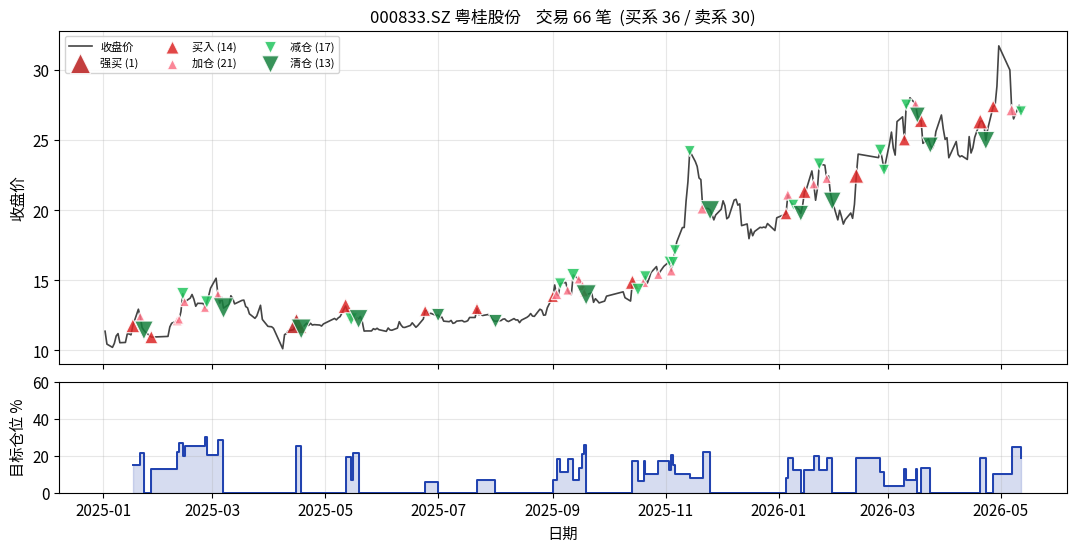

/tmp/ipykernel_1092351/3641239610.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


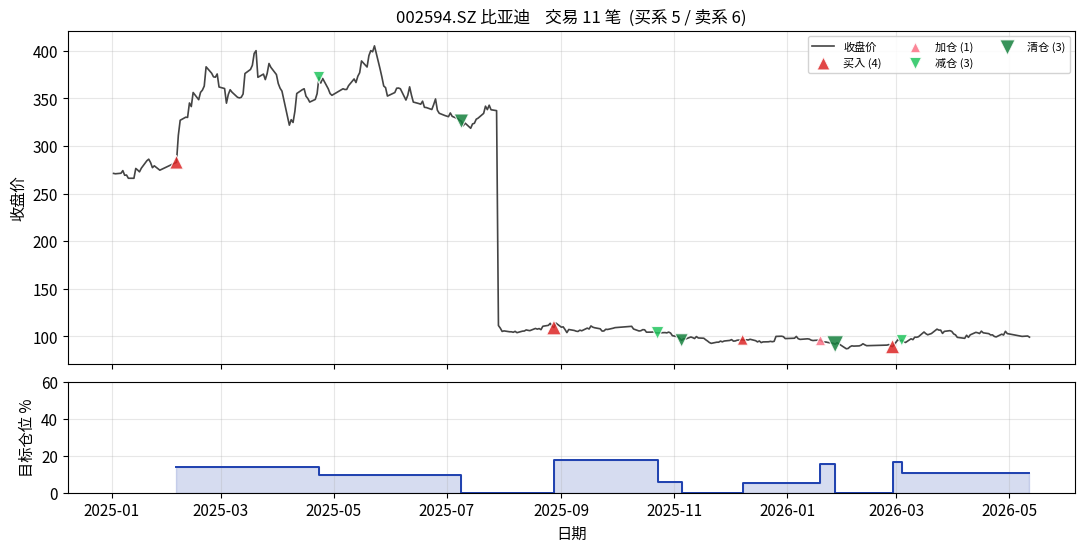

/tmp/ipykernel_1092351/3641239610.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


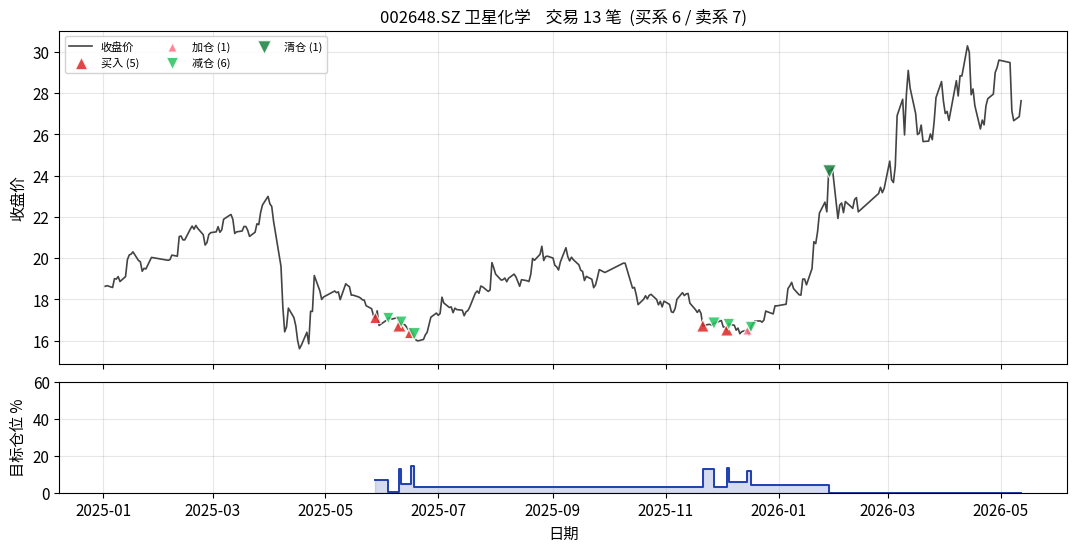

/tmp/ipykernel_1092351/3641239610.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


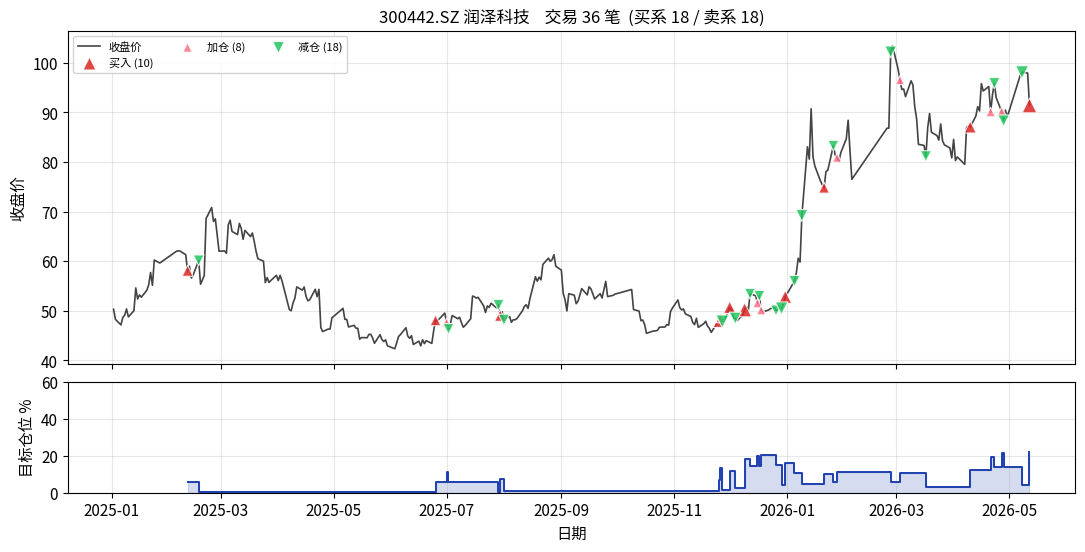

/tmp/ipykernel_1092351/3641239610.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


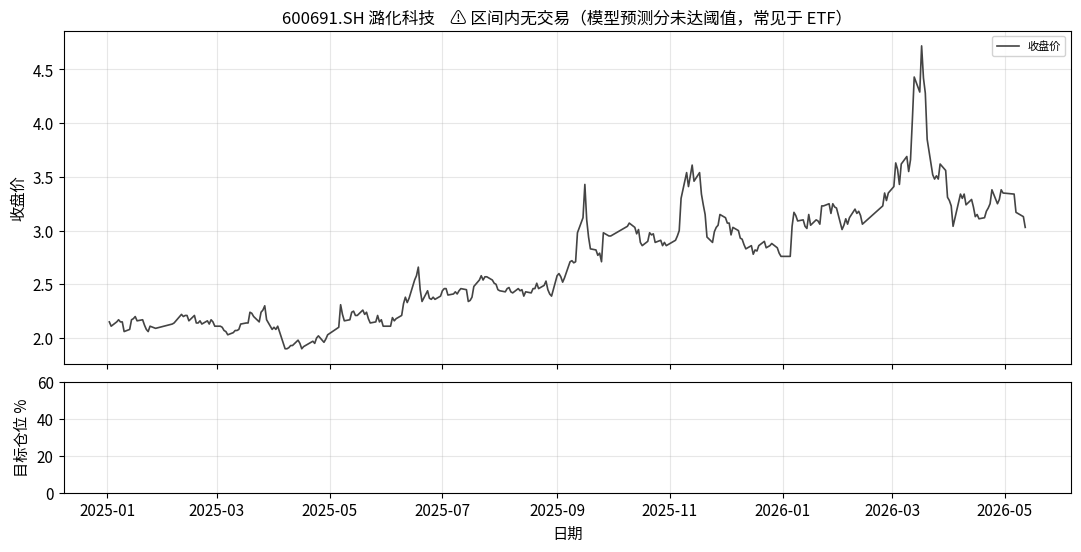

/tmp/ipykernel_1092351/3641239610.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


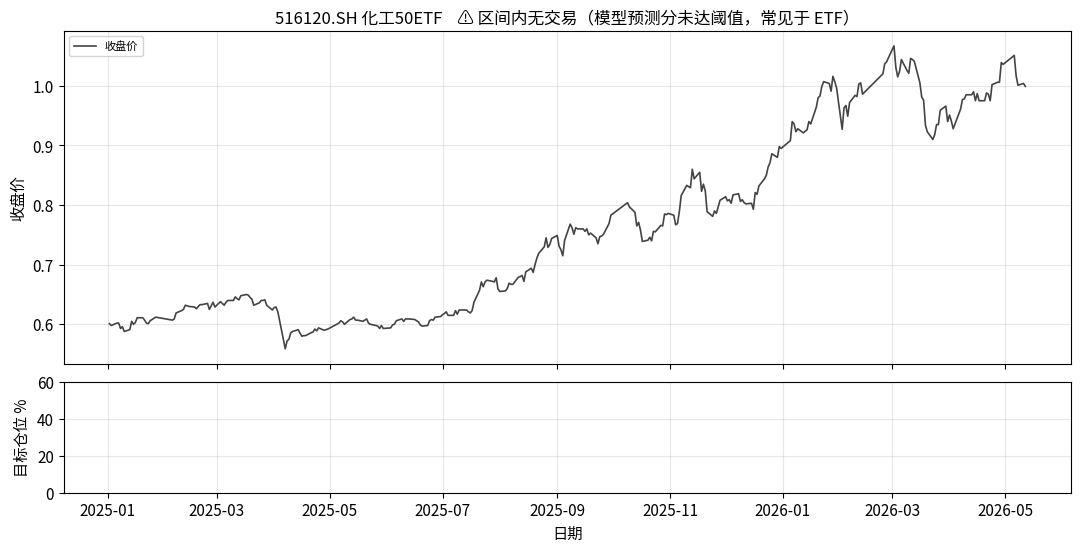

In [24]:
ACTION_STYLE = {
    'strong_buy': dict(color='#b91c1c', marker='^', label='强买', base_size=120),
    'buy':        dict(color='#dc2626', marker='^', label='买入', base_size=80),
    'add':        dict(color='#fb7185', marker='^', label='加仓', base_size=55),
    'reduce':     dict(color='#22c55e', marker='v', label='减仓', base_size=80),
    'clear':      dict(color='#15803d', marker='v', label='清仓', base_size=120),
}

def _marker_size(delta_abs: float, base: float) -> float:
    """size ∝ |weight_delta|，0% → base*0.5，30% → base*2"""
    scale = 0.5 + min(delta_abs, 0.30) / 0.30 * 1.5
    return base * scale

if trade_df.empty:
    print('没有交易记录，无法绘制买卖点')
else:
    for code in all_codes:
        df = engine_bt._price_cache.get(code)
        if df is None or df.empty:
            print(f'  [skip] {code} 无价格缓存')
            continue
        df = df.copy()
        df['date'] = pd.to_datetime(df.index, format='%Y%m%d')
        df = df.sort_values('date')

        sub = trade_df[trade_df['code'] == code].copy()
        if not sub.empty:
            sub['date'] = pd.to_datetime(sub['trade_date'], format='%Y%m%d')
            sub = sub.sort_values('date')

        fig, (ax, ax2) = plt.subplots(
            2, 1, figsize=(13, 6), sharex=True,
            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08},
        )

        ax.plot(df['date'], df['close'], color='#444', linewidth=1.2, label='收盘价', zorder=2)

        if not sub.empty:
            for action in ['strong_buy', 'buy', 'add', 'reduce', 'clear']:
                grp = sub[sub['action'] == action]
                if grp.empty:
                    continue
                style = ACTION_STYLE[action]
                sizes = grp['weight_delta'].abs().apply(
                    lambda d: _marker_size(d, style['base_size'])
                )
                ax.scatter(
                    grp['date'], grp['price'],
                    marker=style['marker'], color=style['color'],
                    s=sizes, alpha=0.85,
                    edgecolors='white', linewidths=0.8,
                    label=f'{style["label"]} ({len(grp)})',
                    zorder=5,
                )

        name = code_name_map.get(code, '')
        n_trades = len(sub)
        n_buy = sub[sub['action'].isin(['strong_buy', 'buy', 'add'])].shape[0] if not sub.empty else 0
        n_sell = sub[sub['action'].isin(['reduce', 'clear'])].shape[0] if not sub.empty else 0
        if sub.empty:
            title_main = f'{code} {name}    ⚠ 区间内无交易（模型预测分未达阈值，常见于 ETF）'
        else:
            title_main = f'{code} {name}    交易 {n_trades} 笔  (买系 {n_buy} / 卖系 {n_sell})'
        ax.set_title(title_main, fontsize=12)
        ax.set_ylabel('收盘价')
        ax.legend(loc='best', ncol=3, fontsize=8, framealpha=0.85)
        ax.grid(alpha=0.3)

        if not sub.empty:
            pos_x = list(sub['date']) + [df['date'].iloc[-1]]
            pos_y = list(sub['weight_after'] * 100) + [sub['weight_after'].iloc[-1] * 100]
            ax2.step(pos_x, pos_y, where='post', color='#1e40af', linewidth=1.4)
            ax2.fill_between(pos_x, 0, pos_y, step='post', alpha=0.18, color='#1e40af')
            ax2.set_ylim(0, max(60, sub['weight_after'].max() * 100 * 1.2))
        else:
            ax2.set_ylim(0, 60)
        ax2.set_ylabel('目标仓位 %')
        ax2.set_xlabel('日期')
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

## 10. 对接今日 Live 信号

回测结束后无缝衔接到当日实盘建议：

1. **数据更新**：主动触发 `DailyPipeline.run(session='afternoon')`，把当天日线 / 估值 / 融资融券 / 北向等增量入库
2. **当前持仓**：用回测末日的模拟仓位作为 `current_positions`，演示"假设一直跟随策略持仓到今天"的效果
3. **今日操作建议**：调 `advisor.advise_batch(latest_trade_date, current_positions=end_positions)`，输出与 [13_daily_advisor.ipynb](./13_daily_advisor.ipynb) 一致的中文表
4. **逐票归因**：SHAP top 特征 + pred_3d/5d/10d + 安全边际 + 止盈
5. **个股图叠加今日点**：在第 9 节已绘制的 K 线图上叠加金色 ★ marker 标记今日操作位置

> 提示：如已在 [09_daily_pipeline.ipynb](./09_daily_pipeline.ipynb) 中跑过 afternoon 管线，可将 `RUN_DAILY_PIPELINE = False` 跳过重复入库。

In [25]:
from invest_model.pipeline.daily_pipeline import DailyPipeline
from datetime import datetime as _dt

RUN_DAILY_PIPELINE = True
PIPELINE_SESSION = 'afternoon'

if RUN_DAILY_PIPELINE:
    print('=' * 60)
    print(f'  daily_pipeline 启动 [{PIPELINE_SESSION}]: {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}')
    print('=' * 60)
    pipeline = DailyPipeline()
    pipeline_results = pipeline.run(session=PIPELINE_SESSION)
    print('=' * 60)
    print('  daily_pipeline 结果汇总:')
    print('=' * 60)
    for step, status in pipeline_results.items():
        icon = '✓' if 'OK' in status else '✗'
        print(f'  {icon} {step}: {status}')
else:
    print('跳过 daily_pipeline（设 RUN_DAILY_PIPELINE = True 主动入库当日数据）')

11:51:53 | INFO    | Tushare 使用自定义接口基地址: http://118.89.66.41:8010/


  daily_pipeline 启动 [afternoon]: 2026-05-13 11:51:53


11:51:54 | INFO    | Tushare 客户端初始化完成（Token 验证通过）
11:51:54 | INFO    | ============================================================
11:51:54 | INFO    | 每日管线启动 [afternoon]: 2026-05-13 11:51:54
11:51:54 | INFO    | 执行步骤: ['calendar', 'stock_list', 'stock_daily', 'etf_daily', 'index_daily', 'daily_basic', 'technical', 'margin', 'cashflow', 'northbound', 'holder_trade', 'holder_count', 'signal_generation', 'validation']
11:51:54 | INFO    | ============================================================
11:51:54 | INFO    | --- [交易日历] 开始 ---
11:51:54 | INFO    | 交易日历已覆盖到 20261231，无需更新
11:51:54 | INFO    | --- [交易日历] 完成: 0 ---
11:51:54 | INFO    | --- [股票列表] 开始 ---
11:51:54 | INFO    | 开始采集 A 股股票列表...
11:51:54 | INFO    | 获取到 5515 只 A 股
11:51:55 | INFO    | 写入 stock_info: 5515 条
11:51:55 | INFO    | 开始采集 ETF 列表...
11:51:56 | INFO    | 获取到 1941 只 ETF
11:51:56 | INFO    | 写入 etf_info: 1941 条
11:51:56 | INFO    | --- [股票列表] 完成: stocks=5515, etfs=1941 ---
11:51:56 | INFO    | --- [个股日线] 开始 ---
11

  daily_pipeline 结果汇总:
  ✓ calendar: OK (0)
  ✓ stock_list: OK (stocks=5515, etfs=1941)
  ✓ stock_daily: OK (10 只, 新增 0 条)
  ✓ etf_daily: OK (1 只, 新增 0 条)
  ✓ index_daily: OK (5 指数, 新增 0 条)
  ✓ daily_basic: OK (0)
  ✓ technical: OK (10 只, 新增 0 条)
  ✓ margin: OK (0)
  ✓ cashflow: OK (5 只, 新增 0 条)
  ✓ northbound: OK (0)
  ✓ holder_trade: OK (6)
  ✓ holder_count: OK (10)
  ✓ signal_generation: OK (date=20260512, codes=5, signals=115, composite=5, advisor=5)
  ✓ validation: OK (checks=20, passed=15, warnings=5)


### 10.1 抽取回测末日仓位作为 current_positions

从 `result.trades` 取每只票最后一笔 `weight_after`；从未交易过的标的视为 0。这就是"假设一直跟随策略到今天"的理论持仓。

In [26]:
end_positions: dict[str, float] = {c: 0.0 for c in all_codes}
for _t in sorted(result.trades, key=lambda x: x.trade_date):
    end_positions[_t.code] = float(_t.weight_after)

bt_end_date = result.nav_df['trade_date'].iloc[-1]
print(f'回测末日：{bt_end_date}')
print(f'末日仓位（将作为今日 current_positions）：')
print('-' * 50)
total_w = 0.0
for c, w in end_positions.items():
    total_w += w
    flag = '  →' if w >= 0.005 else '   '
    print(f'  {flag} {c} {code_name_map.get(c, ""):8s} {w:7.2%}')
print('-' * 50)
print(f'   合计持仓: {total_w:.2%}    现金: {1.0 - total_w:.2%}')

回测末日：20260513
末日仓位（将作为今日 current_positions）：
--------------------------------------------------
    → 000833.SZ 粤桂股份      18.88%
    → 002594.SZ 比亚迪       10.79%
      002648.SZ 卫星化学       0.00%
    → 300442.SZ 润泽科技      21.99%
      600691.SH 潞化科技       0.00%
      516120.SH 化工50ETF    0.00%
--------------------------------------------------
   合计持仓: 51.66%    现金: 48.34%


### 10.2 今日操作建议

**关键：今日 Live 推理使用 `v1` 模型（含最新数据），不是回测用的 `v1_oos`。**

- 回测主体在 cell 6 用了 `v1_oos`（训练截止 2024-12-31），保证回测结果是真 OOS
- 今日实盘建议希望用最新数据训练的模型，所以这里**新建** `advisor_live = StockAdvisor(version='v1')`

表格列与 [13_daily_advisor.ipynb](./13_daily_advisor.ipynb) 第 5 节对齐：操作 / 当前 / 目标 / 调仓 / score / 置信度 / 安全边际 / 止盈 / pred_3d/5d/10d。

In [27]:
from invest_model.repositories.stock_daily_repo import StockDailyRepository as _SDR
from invest_model.repositories.etf_repo import ETFRepository as _ETF

_daily_repo = _SDR(engine)
_etf_repo = _ETF(engine)

_latest_dates = []
for _c in all_codes:
    _d = _daily_repo.get_latest_date(code=_c) or _etf_repo.get_latest_date(_c)
    if _d:
        _latest_dates.append(_d)
today_date = max(_latest_dates) if _latest_dates else bt_end_date
today_fmt = f'{today_date[:4]}-{today_date[4:6]}-{today_date[6:]}'

print(f'今日信号日期: {today_fmt}（数据库最新交易日）')
if today_date > bt_end_date:
    print(f'  → 比回测末日 {bt_end_date} 新 {(_dt.strptime(today_date, "%Y%m%d") - _dt.strptime(bt_end_date, "%Y%m%d")).days} 天，已纳入最新行情')
else:
    print(f'  → 与回测末日一致，可能需要先跑 daily_pipeline 拉今天数据')

LIVE_MODEL_VERSION = 'v1'
print(f'今日推理使用模型版本: {LIVE_MODEL_VERSION}（含最新训练数据，与 13_daily_advisor 一致）')
print(f'今日决策档位: {PRIMARY_TIER}（与回测主档位一致；如需保守可临时改 DECISION_BASE.execution_tier）')

# 复用回测的 DecisionConfig + IC 加权
advisor_live = StockAdvisor(
    engine, version=LIVE_MODEL_VERSION,
    decision_config=DECISION_BASE,
    ic_weighting=True,
)

# 复用回测末日的 last_action_dates（来自主档位 engine）以保持冷却连续性
_last_action_dates = getattr(engines_by_tier[PRIMARY_TIER], '_last_action_dates_cache', None)
# 若回测引擎未暴露，则从 result.trades 反推（按时间倒序找各 code 最近一次开/清仓）
if _last_action_dates is None:
    _last_action_dates = {c: {'open': None, 'clear': None} for c in all_codes}
    for _t in sorted(result.trades, key=lambda x: x.trade_date):
        prev_w = _t.weight_before
        new_w = _t.weight_after
        if prev_w <= 1e-6 and new_w > 1e-6:
            _last_action_dates[_t.code]['open'] = _t.trade_date
        if prev_w > 1e-6 and new_w <= 1e-6:
            _last_action_dates[_t.code]['clear'] = _t.trade_date

today_signals = advisor_live.advise_batch(
    all_codes, today_date, code_name_map,
    current_positions=end_positions,
    last_action_dates=_last_action_dates,
)

today_rows = []
for s in today_signals:
    today_rows.append({
        '代码': s.code,
        '名称': s.name,
        '操作': s.action_cn,
        '当前': f'{s.current_position:.0%}',
        '目标': f'{s.target_position:.0%}',
        '调仓': f'{s.delta_position:+.0%}' if abs(s.delta_position) >= 0.005 else '0%',
        'score': f'{s.horizon_score:+.4f}',
        '置信度': s.confidence,
        '安全边际': f'{s.safety_margin:.2f}',
        '止盈': '✓' if s.take_profit else '',
        'pred_3d': f'{s.sub_scores.get("pred_3d", 0):+.4f}',
        'pred_5d': f'{s.sub_scores.get("pred_5d", 0):+.4f}',
        'pred_10d': f'{s.sub_scores.get("pred_10d", 0):+.4f}',
    })
today_table = pd.DataFrame(today_rows)
display(today_table)

_n_act = sum(1 for s in today_signals if s.action != 'hold')
print(f'\n  今日待执行调仓: {_n_act} 只 / 共 {len(today_signals)} 只')

11:52:30 | INFO    | 加载 ML 模型: 6 只标的 × 3 horizons version=v1 ic_weighting=True


今日信号日期: 2026-05-12（数据库最新交易日）
  → 与回测末日一致，可能需要先跑 daily_pipeline 拉今天数据
今日推理使用模型版本: v1（含最新训练数据，与 13_daily_advisor 一致）
今日决策档位: normal（与回测主档位一致；如需保守可临时改 DECISION_BASE.execution_tier）


,代码,名称,操作,当前,目标,调仓,score,置信度,安全边际,止盈,pred_3d,pred_5d,pred_10d
0,300442.SZ,润泽科技,观望,22%,24%,+2%,+0.0470,100,0.56,,+0.0084,+0.0209,+0.0673
1,000833.SZ,粤桂股份,观望,19%,21%,+2%,+0.0423,100,0.52,,+0.0029,+0.0089,+0.0536
2,002594.SZ,比亚迪,清仓,11%,0%,-11%,-0.0238,100,0.59,,+0.0003,+0.0038,-0.0550
3,600691.SH,潞化科技,买入,0%,16%,+16%,+0.0214,100,0.73,,-0.0004,+0.0018,+0.0243
4,516120.SH,化工50ETF,观望,0%,0%,0%,-0.0010,5,0.63,,-0.0002,-0.0003,-0.0010
5,002648.SZ,卫星化学,观望,0%,0%,0%,+0.0003,1,0.51,,-0.0011,+0.0043,-0.0028



  今日待执行调仓: 2 只 / 共 6 只


### 10.3 逐票归因

每只票输出：决策结果 + 关键预测分 + SHAP top 特征 + 决策注释。

In [28]:
for s in today_signals:
    print('=' * 70)
    print(f'  {s.code} {s.name}  →  {s.action_cn}  '
          f'(置信度 {s.confidence}/100)')
    print(f'  目标 {s.target_position:.0%} | 当前 {s.current_position:.0%} | '
          f'调仓 {s.delta_position:+.0%} | score {s.horizon_score:+.4f} | '
          f'安全边际 {s.safety_margin:.2f}'
          + ('  | 止盈触发' if s.take_profit else ''))
    print(f'  归因: {s.attribution}')
    print()

  300442.SZ 润泽科技  →  观望  (置信度 100/100)
  目标 24% | 当前 22% | 调仓 +2% | score +0.0470 | 安全边际 0.56
  归因: score=+0.0470 target=24% curr=22% safety=0.56 | preds: h3=+0.0084 / h5=+0.0209 / h10=+0.0673 | top: pe_rank=+0.0068, momentum_20=+0.0023, tech_macd_hist=+0.0023, comp_std_5d=+0.0019, macd_trend=+0.0018 | score=+0.0470, safety=0.56, target=24%, current=22%, tier=normal

  000833.SZ 粤桂股份  →  观望  (置信度 100/100)
  目标 21% | 当前 19% | 调仓 +2% | score +0.0423 | 安全边际 0.52
  归因: score=+0.0423 target=21% curr=19% safety=0.52 | preds: h3=+0.0029 / h5=+0.0089 / h10=+0.0536 | top: comp_roll_max_10d=-0.0035, pe_rank=+0.0035, comp_sign_changes_10d=-0.0030, price_momentum_20d=+0.0021, comp_std_5d=-0.0020 | score=+0.0423, safety=0.52, target=21%, current=19%, tier=normal

  002594.SZ 比亚迪  →  清仓  (置信度 100/100)
  目标 0% | 当前 11% | 调仓 -11% | score -0.0238 | 安全边际 0.59
  归因: score=-0.0238 target=0% curr=11% safety=0.59 | preds: h3=+0.0003 / h5=+0.0038 / h10=-0.0550 | top: tech_macd_hist=+0.0062, tech_volatility_2

### 10.4 个股图叠加今日操作

在每只票的 K 线图上叠加：

- **金色 ★ 大号 marker** 标记今日成交价位置（颜色 `#f59e0b`，与历史买卖点颜色完全分开）
- **标题副文本** `今日: <操作> 调仓<delta>`
- 操作为"观望"的也单独显示（用灰色 ◇），便于看出"今天对该票没动作"

/tmp/ipykernel_1092351/545267697.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


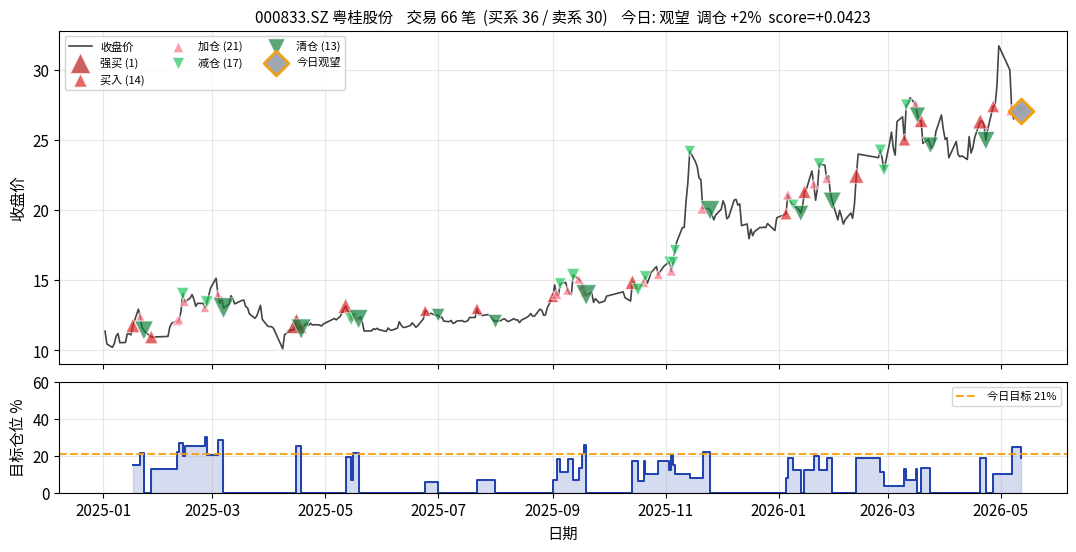

/tmp/ipykernel_1092351/545267697.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


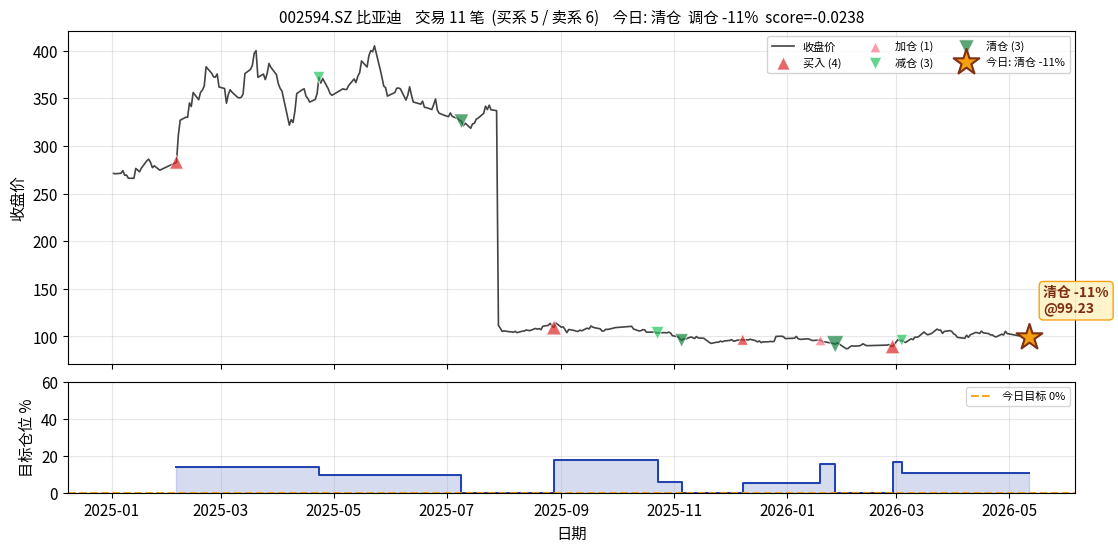

/tmp/ipykernel_1092351/545267697.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


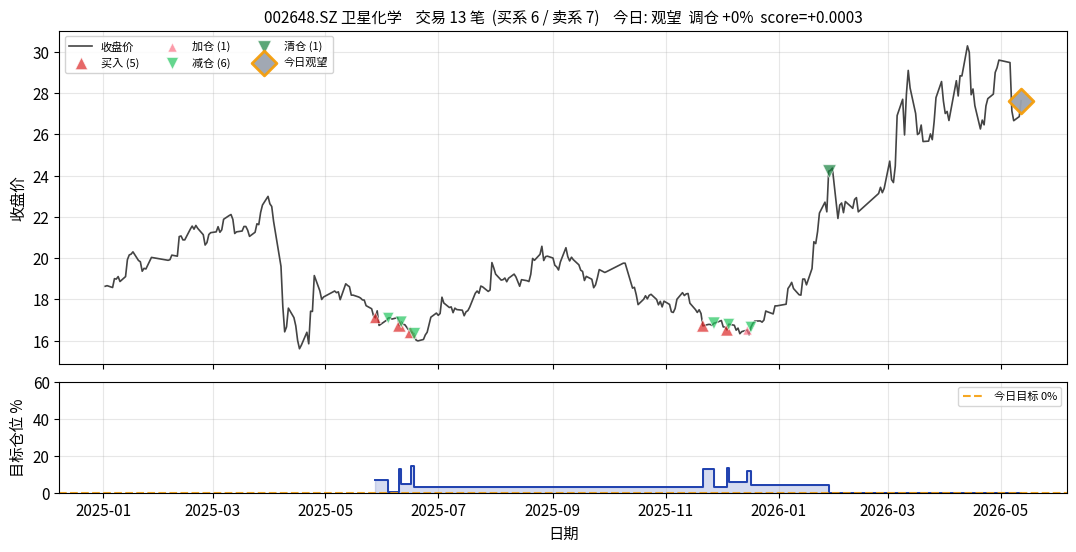

/tmp/ipykernel_1092351/545267697.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


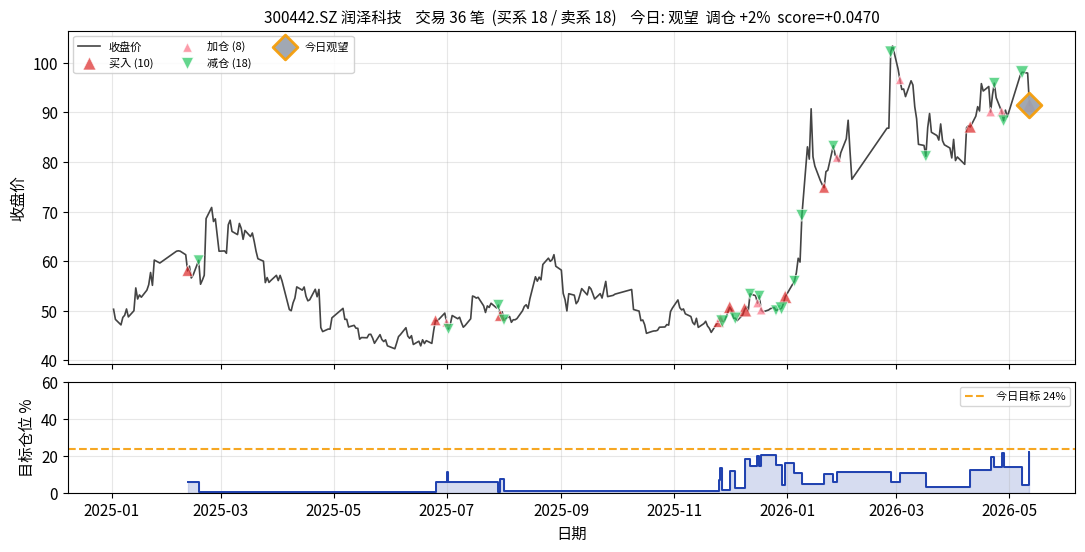

/tmp/ipykernel_1092351/545267697.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


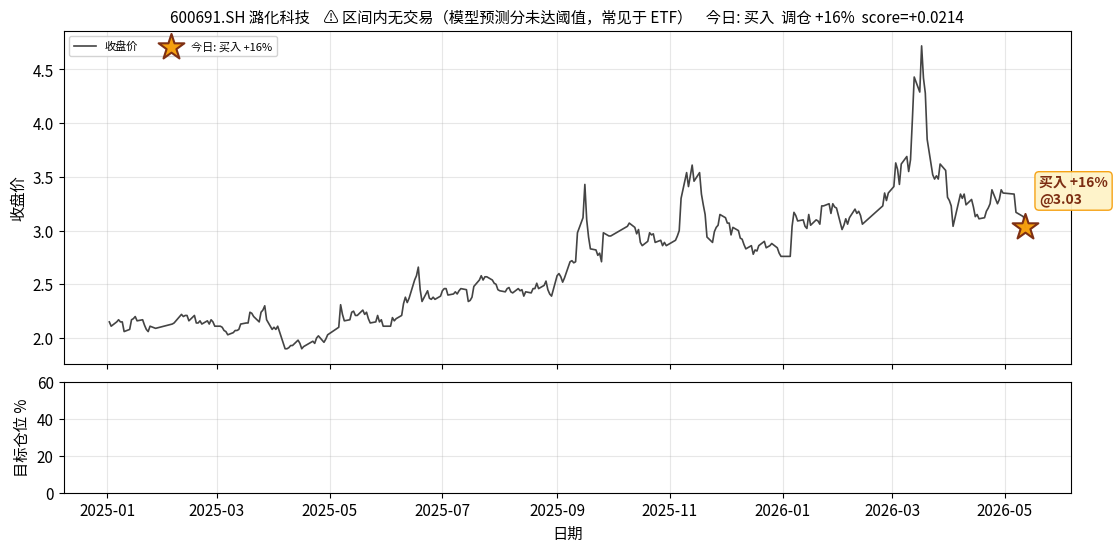

/tmp/ipykernel_1092351/545267697.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


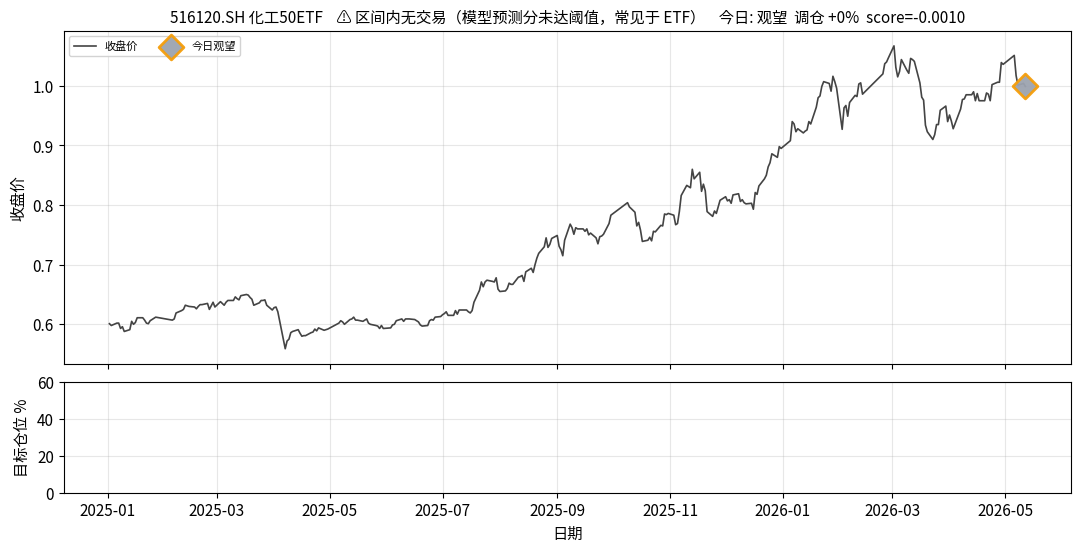

In [29]:
today_sig_map = {s.code: s for s in today_signals}

today_price_lookup: dict[str, float] = {}
for _c in all_codes:
    _df = engine_bt._price_cache.get(_c)
    if _df is not None and today_date in _df.index:
        today_price_lookup[_c] = float(_df.loc[today_date, 'close'])
    else:
        _d = _daily_repo.get_daily(_c, today_date, today_date)
        if _d.empty:
            _d = _etf_repo.get_daily(_c, today_date, today_date)
        if not _d.empty:
            try:
                today_price_lookup[_c] = float(_d.iloc[-1]['close'])
            except (TypeError, ValueError, KeyError):
                pass

ACTION_CN_MAP = {
    'strong_buy': '强买', 'buy': '买入', 'add': '加仓',
    'hold': '观望', 'reduce': '减仓', 'clear': '清仓',
}

for code in all_codes:
    df = engine_bt._price_cache.get(code)
    if df is None or df.empty:
        continue
    df = df.copy()
    df['date'] = pd.to_datetime(df.index, format='%Y%m%d')
    df = df.sort_values('date')

    sub = trade_df[trade_df['code'] == code].copy()
    if not sub.empty:
        sub['date'] = pd.to_datetime(sub['trade_date'], format='%Y%m%d')
        sub = sub.sort_values('date')

    sig = today_sig_map.get(code)
    today_price = today_price_lookup.get(code)
    today_dt = pd.to_datetime(today_date, format='%Y%m%d')

    fig, (ax, ax2) = plt.subplots(
        2, 1, figsize=(13, 6), sharex=True,
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08},
    )

    ax.plot(df['date'], df['close'], color='#444', linewidth=1.2, label='收盘价', zorder=2)

    if not sub.empty:
        for action in ['strong_buy', 'buy', 'add', 'reduce', 'clear']:
            grp = sub[sub['action'] == action]
            if grp.empty:
                continue
            style = ACTION_STYLE[action]
            sizes = grp['weight_delta'].abs().apply(
                lambda d: _marker_size(d, style['base_size'])
            )
            ax.scatter(
                grp['date'], grp['price'],
                marker=style['marker'], color=style['color'],
                s=sizes, alpha=0.7,
                edgecolors='white', linewidths=0.6,
                label=f'{style["label"]} ({len(grp)})',
                zorder=4,
            )

    if sig is not None and today_price is not None:
        if sig.action == 'hold':
            ax.scatter(
                [today_dt], [today_price],
                marker='D', color='#9ca3af', s=160, alpha=0.95,
                edgecolors='#f59e0b', linewidths=2.0,
                label=f'今日观望', zorder=8,
            )
        else:
            today_marker = '^' if sig.action in ('strong_buy', 'buy', 'add') else 'v'
            ax.scatter(
                [today_dt], [today_price],
                marker='*', color='#f59e0b', s=380, alpha=0.98,
                edgecolors='#7c2d12', linewidths=1.5,
                label=f'今日: {sig.action_cn} {sig.delta_position:+.0%}',
                zorder=8,
            )
            ax.annotate(
                f'{sig.action_cn} {sig.delta_position:+.0%}\n@{today_price:.2f}',
                xy=(today_dt, today_price),
                xytext=(10, 18), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#7c2d12',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fef3c7', edgecolor='#f59e0b', alpha=0.95),
            )

    name = code_name_map.get(code, '')
    n_trades = len(sub)
    n_buy = sub[sub['action'].isin(['strong_buy', 'buy', 'add'])].shape[0] if not sub.empty else 0
    n_sell = sub[sub['action'].isin(['reduce', 'clear'])].shape[0] if not sub.empty else 0

    title_parts = [f'{code} {name}']
    if sub.empty:
        title_parts.append('⚠ 区间内无交易（模型预测分未达阈值，常见于 ETF）')
    else:
        title_parts.append(f'交易 {n_trades} 笔  (买系 {n_buy} / 卖系 {n_sell})')
    if sig is not None:
        title_parts.append(
            f'今日: {sig.action_cn}  调仓 {sig.delta_position:+.0%}  score={sig.horizon_score:+.4f}'
        )
    ax.set_title('    '.join(title_parts), fontsize=11)
    ax.set_ylabel('收盘价')
    ax.legend(loc='best', ncol=3, fontsize=8, framealpha=0.85)
    ax.grid(alpha=0.3)

    if not sub.empty:
        pos_x = list(sub['date']) + [df['date'].iloc[-1]]
        pos_y = list(sub['weight_after'] * 100) + [sub['weight_after'].iloc[-1] * 100]
        ax2.step(pos_x, pos_y, where='post', color='#1e40af', linewidth=1.4)
        ax2.fill_between(pos_x, 0, pos_y, step='post', alpha=0.18, color='#1e40af')
        if sig is not None:
            target_pct = sig.target_position * 100
            ax2.axhline(target_pct, color='#f59e0b', linewidth=1.5, linestyle='--', alpha=0.9,
                        label=f'今日目标 {target_pct:.0f}%')
            ax2.legend(loc='best', fontsize=8)
        ax2.set_ylim(0, max(60, sub['weight_after'].max() * 100 * 1.2))
    else:
        ax2.set_ylim(0, 60)
    ax2.set_ylabel('目标仓位 %')
    ax2.set_xlabel('日期')
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()